In [1]:
import os
os.makedirs("images", exist_ok=True)

# 📊 Portfolio Optimization using MPT and CVaR

## Introduction
Portfolio optimization is a financial technique used to balance risk and return. This project applies Modern Portfolio Theory (MPT) and Conditional Value at Risk (CVaR) to construct an optimal portfolio.

## Objective
- Maximize returns  
- Minimize risk  
- Compare MPT and CVaR  

In [2]:
pip install yfinance pandas numpy matplotlib seaborn scipy



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
stocks = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS"]

data = yf.download(stocks, start="2018-01-01", end="2025-01-01")['Close']

data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-01,432.689026,298.055054,415.244293,401.864838,1069.273193
2018-01-02,436.853790,297.478699,413.697388,402.483185,1063.453125
2018-01-03,432.257416,302.569580,410.322571,404.095520,1066.464111
2018-01-04,433.948944,302.281403,407.952240,406.525024,1073.921143
2018-01-05,434.812195,300.552429,406.586212,407.828156,1086.895142


In [5]:
data

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-01,432.689026,298.055054,415.244293,401.864838,1069.273193
2018-01-02,436.853790,297.478699,413.697388,402.483185,1063.453125
2018-01-03,432.257416,302.569580,410.322571,404.095520,1066.464111
2018-01-04,433.948944,302.281403,407.952240,406.525024,1073.921143
2018-01-05,434.812195,300.552429,406.586212,407.828156,1086.895142
...,...,...,...,...,...
2024-12-24,887.059631,1287.317017,1854.176880,1217.885864,3913.823975
2024-12-26,883.433655,1287.416138,1852.574341,1211.710571,3904.085205
2024-12-27,887.133667,1297.538208,1861.655518,1216.192749,3900.105469


In [6]:
data = yf.download(stocks, start="2018-01-01", end="2025-01-01")['Close'].dropna()

[*********************100%***********************]  5 of 5 completed


In [7]:
returns = data.pct_change().dropna()
returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-02,0.009625,-0.001934,-0.003725,0.001539,-0.005443
2018-01-03,-0.010522,0.017113,-0.008158,0.004006,0.002831
2018-01-04,0.003913,-0.000952,-0.005777,0.006012,0.006992
2018-01-05,0.001989,-0.005720,-0.003348,0.003206,0.012081
2018-01-08,-0.001610,0.003995,0.023765,0.005741,0.009371


In [8]:
# Remove extreme returns (optional but advanced)
returns = returns[(returns > -0.5) & (returns < 0.5)]
returns = returns.dropna()

In [9]:
data = data.sort_index()
data = data.drop_duplicates()

In [10]:
data = data.astype(float)

In [11]:
normalized_data = data / data.iloc[0]

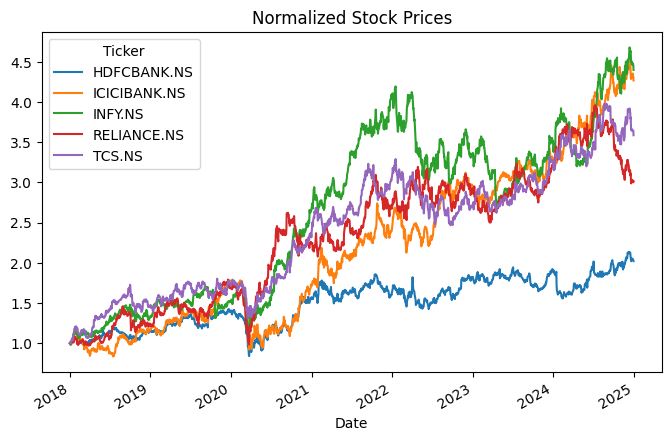

In [12]:
normalized_data.plot(figsize=(8,5))
plt.title("Normalized Stock Prices")
plt.show()

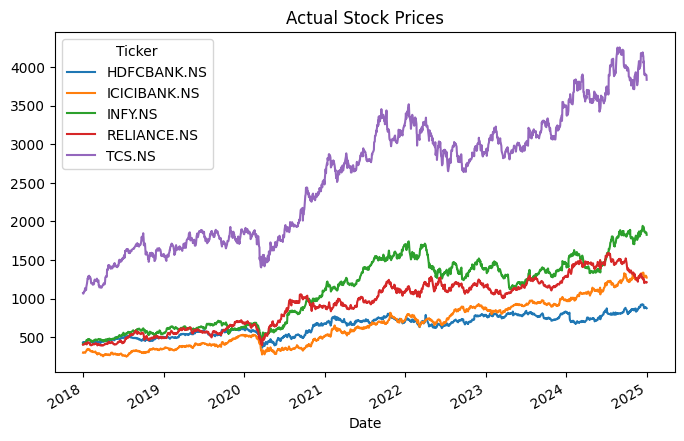

In [13]:
data.plot(figsize=(8,5))
plt.title("Actual Stock Prices")
plt.show()

In [14]:
print("Any null values:", data.isnull().values.any())
print("Shape:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())

Any null values: False
Shape: (1727, 5)
Date range: 2018-01-01 00:00:00 to 2024-12-31 00:00:00


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1727 entries, 2018-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HDFCBANK.NS   1727 non-null   float64
 1   ICICIBANK.NS  1727 non-null   float64
 2   INFY.NS       1727 non-null   float64
 3   RELIANCE.NS   1727 non-null   float64
 4   TCS.NS        1727 non-null   float64
dtypes: float64(5)
memory usage: 81.0 KB


In [16]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print(mean_returns)
print(cov_matrix)


Ticker
HDFCBANK.NS     0.000532
ICICIBANK.NS    0.001035
INFY.NS         0.001008
RELIANCE.NS     0.000805
TCS.NS          0.000858
dtype: float64
Ticker        HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS
Ticker                                                                  
HDFCBANK.NS      0.000249      0.000175  0.000077     0.000115  0.000060
ICICIBANK.NS     0.000175      0.000387  0.000092     0.000142  0.000072
INFY.NS          0.000077      0.000092  0.000297     0.000091  0.000167
RELIANCE.NS      0.000115      0.000142  0.000091     0.000332  0.000088
TCS.NS           0.000060      0.000072  0.000167     0.000088  0.000237


In [17]:
num_portfolios = 5000

results = []

for _ in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    sharpe = portfolio_return / portfolio_risk
    
    results.append([portfolio_return, portfolio_risk, sharpe])

In [18]:
results = np.array(results)

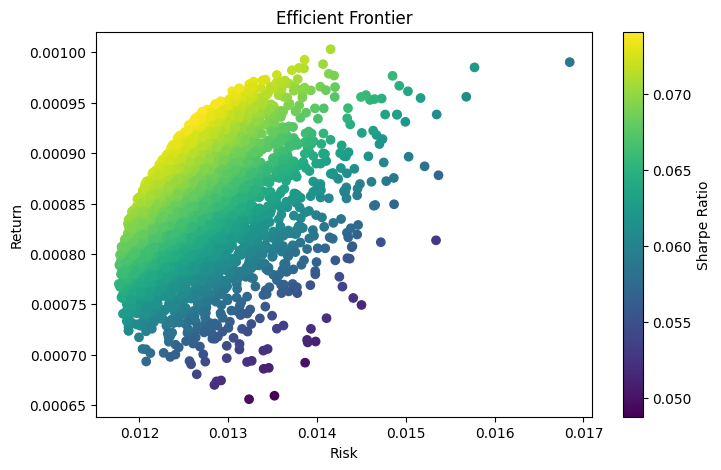

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(results[:,1], results[:,0], c=results[:,2])
plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.savefig("images/efficient_frontier.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def calculate_cvar(portfolio_returns, alpha=0.05):
    var = np.percentile(portfolio_returns, 100 * alpha)
    cvar = portfolio_returns[portfolio_returns <= var].mean()
    return var, cvar

In [21]:
weights = np.random.random(len(stocks))
weights /= np.sum(weights)

portfolio_returns = returns.dot(weights)

var, cvar = calculate_cvar(portfolio_returns)

print("VaR:", var)
print("CVaR:", cvar)

VaR: -0.016681432036646973
CVaR: -0.02793294626318673


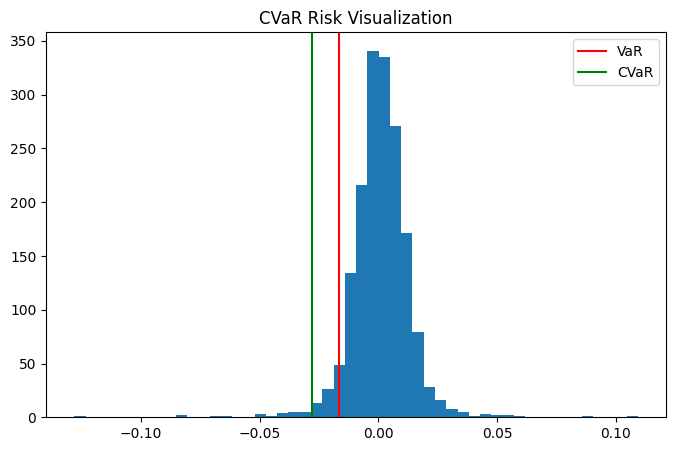

In [22]:
plt.figure(figsize=(8,5))
plt.hist(portfolio_returns, bins=50)

plt.axvline(var, color='red', label='VaR')
plt.axvline(cvar, color='green', label='CVaR')

plt.legend()
plt.title("CVaR Risk Visualization")
plt.savefig("images/cvar_histogram.png", dpi=150, bbox_inches='tight')
plt.show()

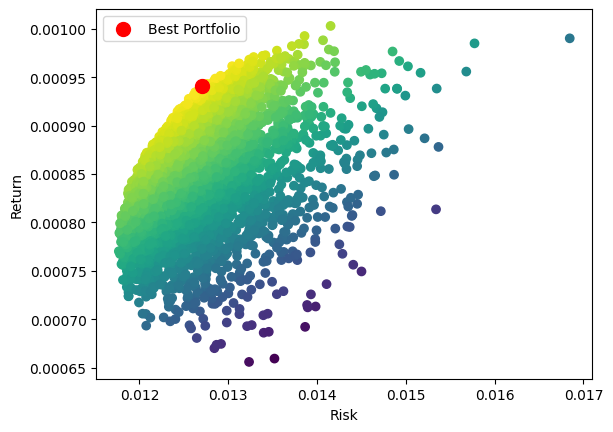

In [23]:
max_idx = np.argmax(results[:,2])

best_return = results[max_idx][0]
best_risk = results[max_idx][1]

plt.scatter(results[:,1], results[:,0], c=results[:,2])
plt.scatter(best_risk, best_return, color='red', s=100, label='Best Portfolio')

plt.xlabel("Risk")
plt.ylabel("Return")
plt.legend()
plt.savefig("images/best_portfolio.png", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
max_idx = np.argmax(results[:,2])

# regenerate weights for best portfolio (simple approach)
best_weights = np.random.random(len(stocks))
best_weights /= np.sum(best_weights)

for stock, weight in zip(stocks, best_weights):
    print(stock, ":", round(weight, 3))

RELIANCE.NS : 0.09
TCS.NS : 0.288
INFY.NS : 0.187
HDFCBANK.NS : 0.196
ICICIBANK.NS : 0.239


In [25]:
print("Best Sharpe Ratio:", results[max_idx][2])

Best Sharpe Ratio: 0.07407441101227846


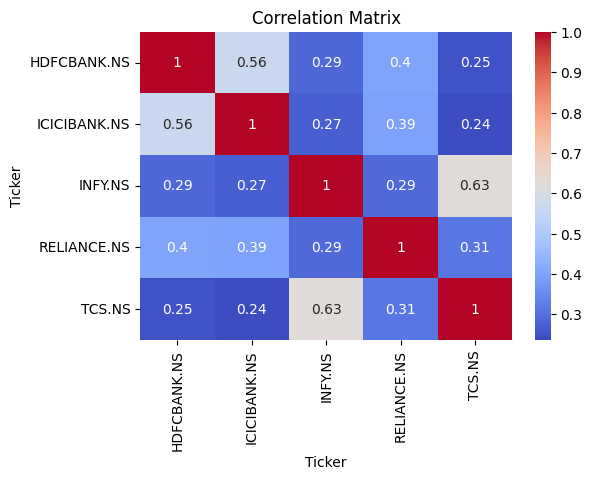

In [26]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("images/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("MPT Risk (std dev):", best_risk)
print("CVaR Risk:", cvar)

MPT Risk (std dev): 0.012703754561677535
CVaR Risk: -0.02793294626318673


In [28]:
print("Expected Return:", best_return)
print("Portfolio Risk:", best_risk)

Expected Return: 0.0009410231368008092
Portfolio Risk: 0.012703754561677535


## Backtesting
Backtesting evaluates how the portfolio would perform over time using historical data.

In [29]:
results = []
weights_record = []

for _ in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    
    weights_record.append(weights)
    
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    sharpe = portfolio_return / portfolio_risk
    
    results.append([portfolio_return, portfolio_risk, sharpe])

results = np.array(results)
weights_record = np.array(weights_record)

In [30]:
best_idx = np.argmax(results[:,2])
best_weights = weights_record[best_idx]
best_weights

array([0.00103338, 0.271266  , 0.32272929, 0.13108855, 0.27388279])

In [31]:
print("----- Optimal Portfolio Allocation -----")

for stock, weight in zip(stocks, best_weights):
    print(f"{stock}: {round(weight*100,2)}%")

----- Optimal Portfolio Allocation -----
RELIANCE.NS: 0.1%
TCS.NS: 27.13%
INFY.NS: 32.27%
HDFCBANK.NS: 13.11%
ICICIBANK.NS: 27.39%


## Final Observation

- MPT optimized portfolio provides better risk-adjusted returns.
- Equal-weight portfolio is simple but less efficient.
- CVaR helps identify extreme downside risks.

In [32]:
# Equal weights portfolio
equal_weights = np.ones(len(stocks)) / len(stocks)

equal_returns = returns.dot(equal_weights)

# MPT best portfolio (Sharpe)
max_idx = np.argmax(results[:,2])
best_return = results[max_idx][0]
best_risk = results[max_idx][1]

print("Equal Portfolio Mean Return:", equal_returns.mean())
print("MPT Portfolio Return:", best_return)
print("MPT Portfolio Risk:", best_risk)

Equal Portfolio Mean Return: 0.0008475694750656471
MPT Portfolio Return: 0.0009470752062918544
MPT Portfolio Risk: 0.012779546542854441


In [33]:
portfolio_returns = returns.dot(equal_weights)

var, cvar = calculate_cvar(portfolio_returns)

print("Mean Return:", portfolio_returns.mean())
print("Standard Risk:", portfolio_returns.std())
print("VaR:", var)
print("CVaR:", cvar)

Mean Return: 0.0008475694750656471
Standard Risk: 0.012096802692793625
VaR: -0.015767405694757666
CVaR: -0.027276859983078484


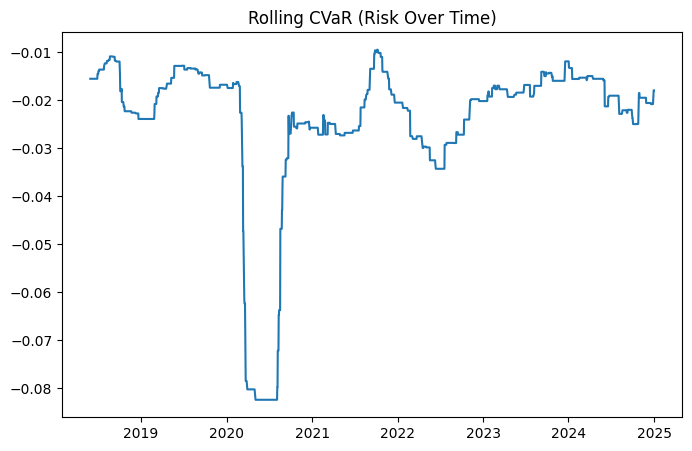

In [34]:
rolling_cvar = portfolio_returns.rolling(window=100).apply(
    lambda x: calculate_cvar(x)[1]
)

plt.figure(figsize=(8,5))
plt.plot(rolling_cvar)
plt.title("Rolling CVaR (Risk Over Time)")
plt.savefig("images/rolling_cvar.png", dpi=150, bbox_inches='tight')
plt.show()

## Comparison of Strategies
We compare equal-weight portfolio, MPT optimized portfolio, and CVaR risk to understand performance differences.

In [35]:
# Equal weights portfolio
equal_weights = np.ones(len(stocks)) / len(stocks)

equal_returns = returns.dot(equal_weights)

# MPT best portfolio
max_idx = np.argmax(results[:,2])
best_return = results[max_idx][0]
best_risk = results[max_idx][1]

print("------ COMPARISON ------")
print("Equal Return:", equal_returns.mean())
print("Equal Risk:", equal_returns.std())

print("MPT Return:", best_return)
print("MPT Risk:", best_risk)

print("CVaR:", cvar)

------ COMPARISON ------
Equal Return: 0.0008475694750656471
Equal Risk: 0.012096802692793625
MPT Return: 0.0009470752062918544
MPT Risk: 0.012779546542854441
CVaR: -0.027276859983078484


## Key Insights

- Diversification reduces portfolio risk.
- MPT provides optimal risk-return balance.
- CVaR captures extreme losses better than variance.
- MPT portfolios generally perform better than equal-weight portfolios.
- CVaR is useful for downside risk protection.

## Conclusion

This project demonstrates that portfolio optimization using MPT improves return efficiency, while CVaR enhances risk management by focusing on extreme losses. Combining both provides a more robust investment strategy.